# Restaurants - classification problem

### Imports and setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression as LRSelector
from sklearn.preprocessing import TargetEncoder
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

### Load Data

Loading the raw training and test datasets and immediately apply feature engineering function. Instead of using raw spatial and temporal lags, compressig them into highly predictive gradients:
1. **Temporal Trends:** Capturing rating momentum and review volume trends over time.
2. **Spatial Density:** Creating ratios between 500m and 2000m catchments to understand local saturation.
3. **Engagement & Audience:** Measuring text review rates and the rating gap between local and foreign tourists.

After extracting these strong signals, dropping the highly collinear raw columns to reduce noise.

In [17]:
train_df = pd.read_csv('data/restaurants_train.csv')
test_df = pd.read_csv('data/restaurants_test.csv')

def engineer_and_drop(df):
    df_eng = df.copy()
    
    # Has Recent Activity flag
    df_eng['has_recent_activity'] = (~df_eng['ratings_num_1m_prior'].isna() & (df_eng['ratings_num_1m_prior'] > 0)).astype(int)
    
    # Temporal Information 
    df_eng['rating_momentum'] = df_eng['ratings_avg_1m_prior'] - df_eng['ratings_avg_12m_prior']
    df_eng['rating_vol_trend'] = df_eng['ratings_num_1m_prior'] - df_eng['ratings_num_3m_prior']
    
    # Spatial Scale Information
    df_eng['competition_density_ratio'] = df_eng['catch_restaurant_count_500m'] / (df_eng['catch_restaurant_count_2000m'] + 1)
    df_eng['local_quality_advantage'] = df_eng['rating_avg'] - df_eng['catch_rating_avg_500m']
    df_eng['age_vs_competition'] = df_eng['place_age_days'] - df_eng['catch_place_age_days_500m']
    
    # Rating Distribution Shape
    df_eng['rating_polarization'] = (df_eng['rating_1'] + df_eng['rating_5']) / (df_eng['user_ratings_total'] + 1)
    df_eng['rating_negative_share'] = (df_eng['rating_1'] + df_eng['rating_2']) / (df_eng['user_ratings_total'] + 1)
    
    # Review Text Engagement
    df_eng['engaged_review_count'] = df_eng['user_ratings_total'] * df_eng['review_has_text_pct']
    
    # Tourist vs. Local Gap
    df_eng['local_tourist_rating_gap'] = df_eng['rating_pl'].fillna(df_eng['rating_avg']) - \
                                         df_eng['rating_foreign'].fillna(df_eng['rating_avg'])
    
    # POI Gradient
    df_eng['poi_cluster_ratio'] = df_eng['poi_count_500m'] / (df_eng['poi_count_2000m'] + 1)
    
    # Interaction
    df_eng['income_unemp_interaction'] = df_eng['gus_64428'] * df_eng['gus_79214']

    df_eng['category_top20'] = df_eng['category_top20'].astype(str).replace('nan', 'Unknown')
    
    # Only drop features directly consumed by engineered features.
    # Keep intermediate spatial scales (1000m) and temporal features to let L1 regularization handle remaining redundancy.
    cols_to_drop = [
        'ratings_num_3m_prior', 'ratings_num_12m_prior',
        'ratings_avg_12m_prior',
        'catch_restaurant_count_2000m', 'catch_rating_avg_2000m', 'catch_place_age_days_2000m',
        'rating_5', 'rating_1', 'rating_2',
        'rating_pl', 'rating_foreign',
        'poi_count_2000m'
    ]
    return df_eng.drop(columns=cols_to_drop, errors='ignore')

# Apply transformations
train_df_eng = engineer_and_drop(train_df)
test_df_eng = engineer_and_drop(test_df)
print(f"Engineered train shape: {train_df_eng.shape}")

Engineered train shape: (33296, 86)


Understanding the distribution of the dependent variable (`status_closed`) is the most critical step. The dataset is highly imbalanced, which suggests the use of SMOTE, Undersampling, and custom class weights.

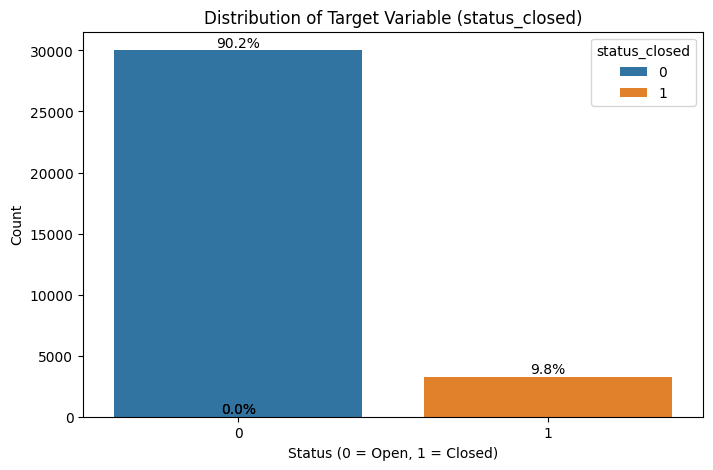

In [18]:
# visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='status_closed', hue = 'status_closed')
plt.title('Distribution of Target Variable (status_closed)')
plt.xlabel('Status (0 = Open, 1 = Closed)')
plt.ylabel('Count')

# Add percentage labels above bars
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

In real-world data missingness is the information itself. A lack of recent reviews or specific tags might be a strong indicator that a restaurant is struggling or already abandoned. Here, we analyze the sparsest columns. 
*(Note: ML pipelines will handle this later using `add_indicator=True` to capture the signal hidden in these missing values).*

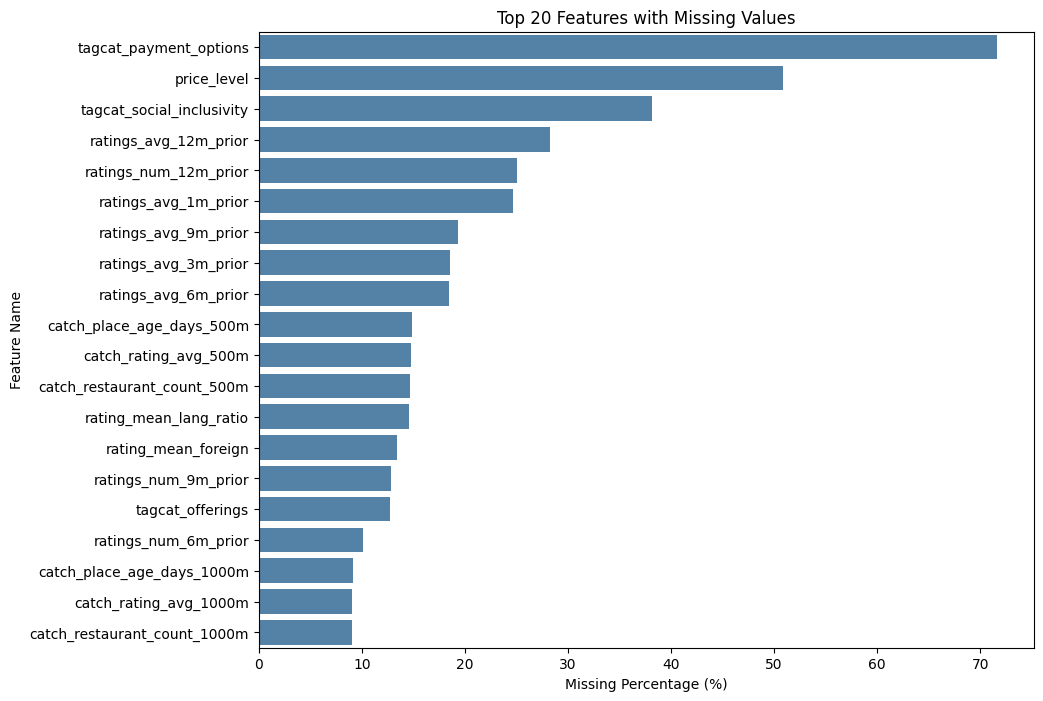

In [19]:
missing_counts = train_df.isnull().sum()
missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_percentage = (missing_features / len(train_df)) * 100

# plot the top 20 features with the highest percentage of missing values
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_percentage.values[:20], y=missing_percentage.index[:20], color='steelblue')
plt.title('Top 20 Features with Missing Values')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Feature Name')
plt.show()

Examination of how categorical attributes like price tier (`price_level`) or the presence of a profile photo (`has_photo`) impact the probability of a restaurant closing.

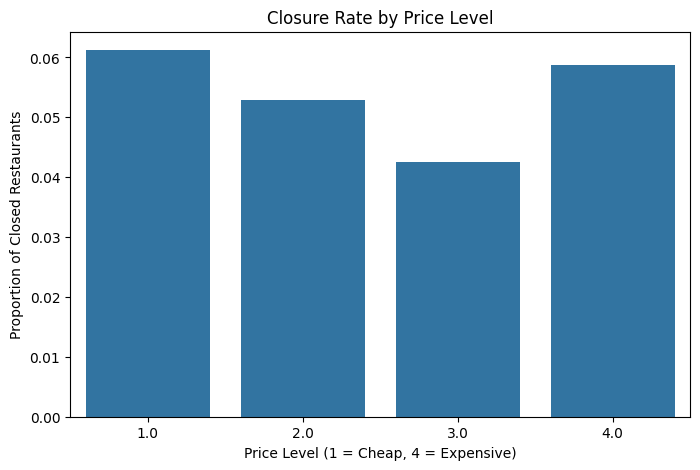

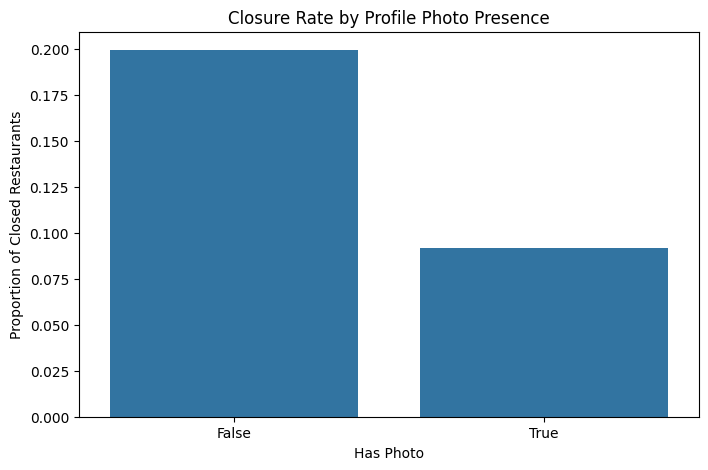

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='price_level', y='status_closed', errorbar=None)
plt.title('Closure Rate by Price Level')
plt.xlabel('Price Level (1 = Cheap, 4 = Expensive)')
plt.ylabel('Proportion of Closed Restaurants')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='has_photo', y='status_closed', errorbar=None)
plt.title('Closure Rate by Profile Photo Presence')
plt.xlabel('Has Photo')
plt.ylabel('Proportion of Closed Restaurants')
plt.show()

Continuous variables like ratings often suffer from severe skewness (e.g., a few restaurants have tens of thousands of reviews, while most have very few). The density of these features is compared between open and closed restaurants to see if they offer predictive power.

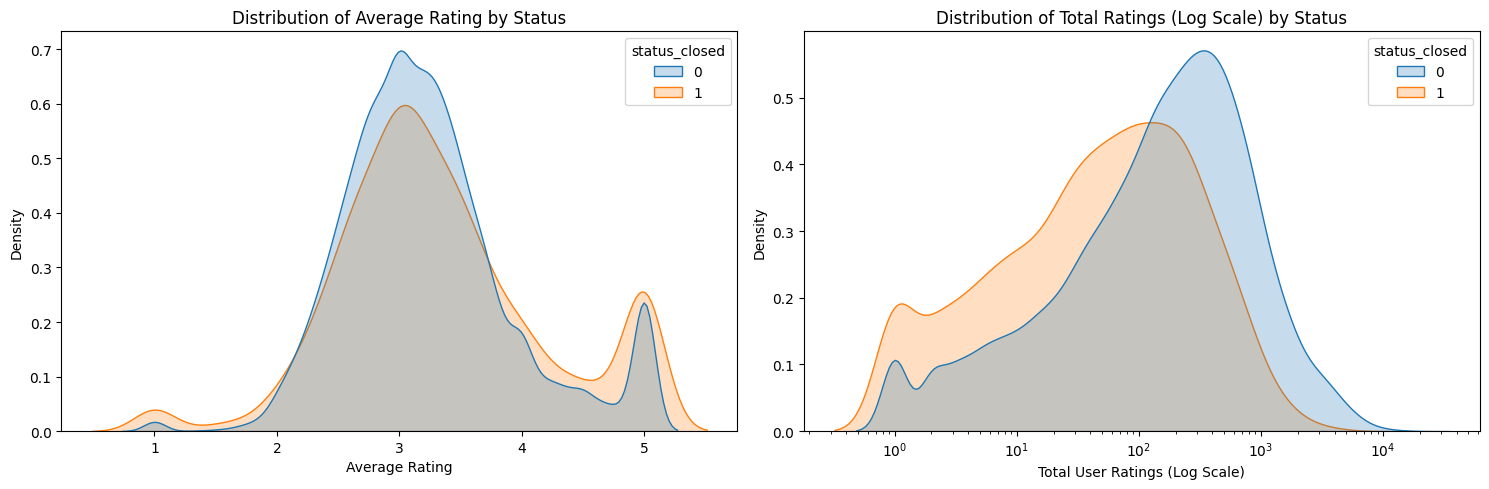

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# plot 1: Average Rating
sns.kdeplot(data=train_df, x='rating_avg', hue='status_closed', common_norm=False, fill=True, ax=axes[0])
axes[0].set_title('Distribution of Average Rating by Status')
axes[0].set_xlabel('Average Rating')

# plot 2: Total User Ratings
sns.kdeplot(data=train_df, x='user_ratings_total', hue='status_closed', common_norm=False, fill=True, log_scale=True, ax=axes[1])
axes[1].set_title('Distribution of Total Ratings (Log Scale) by Status')
axes[1].set_xlabel('Total User Ratings (Log Scale)')

plt.tight_layout()
plt.show()

### Preprocessing

To prevent data leakage and keep the code clean, blueprints for data transformation were defined using `ColumnTransformer`. 

* **Numeric Features:** Missing values are imputed with the median, and a missing indicator is added `PowerTransformer` (Yeo-Johnson) is applyed to fix severe skewness, or a `MinMaxScaler` specifically for distance-based algorithms like KNN.
* **Categorical Features:** Missing values are explicitly flagged as `'Unknown'` so the model can learn from them, followed by standard One-Hot Encoding.
* **Target Encoding:** For the high-cardinality `category_top20` feature, `TargetEncoder` embedded inside the pipeline was used. This ensures the encoding is calculated strictly on the training folds during Cross-Validation, preventing any target leakage into the validation set.

In [22]:


# separate features and target
X_raw = train_df_eng.drop(columns=['restaurant_id', 'status_closed'])
y_raw = train_df_eng['status_closed']
X_test_kaggle = test_df_eng.drop(columns=['restaurant_id'])

# group the columns
target_enc_col = ['category_top20'] 
cat_cols = ['price_level', 'has_photo', 'type_meal_takeaway', 
            'type_meal_delivery', 'type_bar', 'type_cafe', 'type_night_club', 
            'weekends_only', 'workdays_only', 'affiliated']
num_cols = [col for col in X_raw.columns if col not in cat_cols and col not in target_enc_col]

for col in cat_cols + target_enc_col:
    X_raw[col] = X_raw[col].fillna('Unknown').astype(str)
    X_test_kaggle[col] = X_test_kaggle[col].fillna('Unknown').astype(str)

# build the component pipelines
numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), 
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

target_encoding_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('target_enc', TargetEncoder(target_type='binary'))
])

# combine them into the Master Preprocessor
master_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('target', target_encoding_transformer, target_enc_col)
])

# KNN Specific Preprocessor (MinMaxScaler instead of PowerTransformer)
numeric_transformer_knn = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), 
    ('scaler', MinMaxScaler()) 
])
preprocessor_knn = ColumnTransformer(transformers=[
    ('num', numeric_transformer_knn, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('target', target_encoding_transformer, target_enc_col) 
])

### Train/Test split

In [23]:
# split the data randomly into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=123
)

# cross-validation
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
print("Data successfully preprocessed and split!")

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Data successfully preprocessed and split!
Training set size: (26636, 84)
Validation set size: (6660, 84)


## Defining and Training the Models

Three different ML1 algorithms were tested. For each, we use `GridSearchCV` with 5-fold Stratified Cross-Validation (`cv=5`) to find the optimal hyperparameters.

### Logistic Regression / Elastic net

Elastic Net combines L1 (LASSO) and L2 (Ridge) penalties. Integrated `SMOTE` is used directly into the pipeline to synthesize minority class examples and help the linear model find a balanced decision boundary.

aprox.270 minutes

In [24]:
elastic_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(master_preprocessor)),
    ('smote', SMOTE(random_state=123)),
    ('model', LogisticRegression(solver='saga', max_iter=10000, random_state=123))
])

grid_elastic = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid={'model__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0], 'model__l1_ratio': [0, 0.1, 0.5, 0.7, 0.9, 1.0]},
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training Elastic Net...")
grid_elastic.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_elastic.best_params_}")
print(f"Elastic Net CV Balanced Accuracy: {grid_elastic.best_score_:.4f}")

Training Elastic Net...
Best Hyperparameters: {'model__C': 0.1, 'model__l1_ratio': 0.9}
Elastic Net CV Balanced Accuracy: 0.6760


### Logistic Regression with class_weight='balanced' (no SMOTE)

aprox. 

In [25]:
balanced_lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(master_preprocessor)),
    ('model', LogisticRegression(solver='saga', max_iter=10000, random_state=123, class_weight='balanced'))
])

grid_balanced_lr = GridSearchCV(
    estimator=balanced_lr_pipeline,
    param_grid={'model__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0], 'model__l1_ratio': [0, 0.1, 0.5, 0.7, 0.9, 1.0]},
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training Elastic Net...")
grid_balanced_lr.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_balanced_lr.best_params_}")
print(f"Elastic Net CV Balanced Accuracy: {grid_balanced_lr.best_score_:.4f}")

Training Elastic Net...
Best Hyperparameters: {'model__C': 0.1, 'model__l1_ratio': 0.1}
Elastic Net CV Balanced Accuracy: 0.6811


### K-nearest neighbours (KNN)
KNN is a distance-based, non-parametric model that suffers from the "curse of dimensionality". To combat this, L1-regularized Logistic Regression (`SelectFromModel`) was integrated before the KNN algorithm to silently drop noisy and irrelevant features. `SMOTE` and test different distance metrics (Manhattan `p=1` vs Euclidean `p=2`) are also utilized.

aprox 5 minutes

In [26]:
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor_knn)),
    ('selector', SelectFromModel(LRSelector(l1_ratio=1.0, solver='saga', C=0.1, max_iter=5000, random_state=123))),
    ('smote', SMOTE(random_state=123)),
    ('model', KNeighborsClassifier())
])

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={
        'model__n_neighbors': [15, 30, 50],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2] 
    },
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training KNN (with L1 feature selection)...")
grid_knn.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_knn.best_params_}")
print(f"KNN CV Balanced Accuracy: {grid_knn.best_score_:.4f}")

Training KNN (with L1 feature selection)...
Best Hyperparameters: {'model__n_neighbors': 50, 'model__p': 1, 'model__weights': 'distance'}
KNN CV Balanced Accuracy: 0.6312


### Support Vector Machine (SVM)

SVM attempts to find the optimal hyperplane separating open and closed restaurants using an RBF kernel. Here, the imbalance is tackled mathematically by setting `class_weight='balanced'`, forcing the model to penalize mistakes on the minority class much more heavily.

aprox 120 minutes

In [27]:
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(master_preprocessor)),
    #('undersampler', RandomUnderSampler(random_state=123)), # Mandatory for SVM speed, remove class_weight='balanced' if uncommented
    ('model', SVC(random_state=123, probability=True, class_weight='balanced'))])

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid={
        'model__C': [0.1, 1.0, 10.0],
        'model__gamma': ['scale', 'auto'],
        'model__kernel': ['rbf'] 
    },
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training SVM...")
grid_svm.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_svm.best_params_}")
print(f"SVM CV Balanced Accuracy: {grid_svm.best_score_:.4f}")

Training SVM...
Best Hyperparameters: {'model__C': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
SVM CV Balanced Accuracy: 0.6722


### SVM with RandomUnderSampler

Standard SVM training scales quadratically ($O(n^2)$) with the number of samples. To drastically speed up training and often improve the clarity of the decision boundary, this pipeline uses `RandomUnderSampler` to shrink the majority class to match the minority class before fitting the SVM.

aprox 5 minutes

In [28]:
# Undersampled SVM: faster training
svm_under_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(master_preprocessor)),
    ('undersampler', RandomUnderSampler(random_state=123)),
    ('model', SVC(random_state=123, probability=True))
])

grid_svm_u = GridSearchCV(
    estimator=svm_under_pipeline,
    param_grid={
        'model__C': [0.1, 1.0, 10.0],
        'model__gamma': ['scale', 'auto'],
        'model__kernel': ['rbf']
    },
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training Undersampled SVM...")
grid_svm_u.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_svm_u.best_params_}")
print(f"SVM (Undersampled) CV Balanced Accuracy: {grid_svm_u.best_score_:.4f}")

Training Undersampled SVM...
Best Hyperparameters: {'model__C': 1.0, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
SVM (Undersampled) CV Balanced Accuracy: 0.6692


### Model Evaluaton

In this final phase:
1. Automatically identified the best-performing model from the GridSearches.
2. Threshold Tuning: The default 0.5 probability decision threshold is rarely optimal for imbalanced datasets. We use `cross_val_predict` on the training set to find the exact threshold that maximizes Balanced Accuracy, ensuring zero data leakage into the validation set.
3. Evaluate the optimized model securely on untouched Validation set.
4. Retrain the winning model on the entire dataset and generate the final submission CSV.

In [29]:
searches = {
    'Elastic Net (SMOTE)': grid_elastic,
    'Elastic Net (balanced)': grid_balanced_lr,
    'KNN': grid_knn,
    'SVM (RBF, balanced)': grid_svm,
    'SVM (RBF, undersampled)': grid_svm_u
}

best_overall_name = ""
best_overall_score = 0
best_model = None

for name, search_obj in searches.items():
    if search_obj.best_score_ > best_overall_score:
        best_overall_score = search_obj.best_score_
        best_model = search_obj.best_estimator_
        best_overall_name = name

print("-" * 50)
print(f"BEST MODEL: {best_overall_name}")
print(f"Best CV Balanced Accuracy: {best_overall_score:.4f}")
print("-" * 50)

# use of cross_val_predict on X_train to get unbiased, out-of-fold probabilities.
print("\nCalculating Out-Of-Fold probabilities...")
oof_train_probs = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

thresholds = np.linspace(0.2, 0.8, 100)
best_threshold = 0.5
best_train_bacc = 0

# optimize threshold strictly on the out-of-fold training data
for t in thresholds:
    custom_preds = (oof_train_probs >= t).astype(int)
    score = balanced_accuracy_score(y_train, custom_preds)
    if score > best_train_bacc:
        best_train_bacc = score
        best_threshold = t

print(f"Optimal Threshold (Found via CV on Train): {best_threshold:.3f}")

val_probs = best_model.predict_proba(X_val)[:, 1]
final_val_preds = (val_probs >= best_threshold).astype(int)

print(f"Validation Balanced Accuracy (Default 0.5 threshold): {balanced_accuracy_score(y_val, best_model.predict(X_val)):.4f}")
print(f"Validation Balanced Accuracy (OPTIMIZED Threshold): {balanced_accuracy_score(y_val, final_val_preds):.4f}")


# FINAL SUBMISSION PREPARATION

print(f"\nRetraining {best_overall_name} on the FULL training dataset...")
best_model.fit(X_raw, y_raw)

# generate probabilities for the test set
test_probs = best_model.predict_proba(X_test_kaggle)[:, 1]

# apply the optimized threshold
final_test_predictions = (test_probs >= best_threshold).astype(int)

# create submission dataframe
submission = pd.DataFrame({
    'restaurant_id': test_df['restaurant_id'],
    'status_closed': final_test_predictions
})

# save to CSV
submission_filename = f'nfe_submission_best_{best_overall_name.replace(" ", "_")}.csv'
submission.to_csv(submission_filename, index=False)
print(f"Submission saved to {submission_filename}!")

--------------------------------------------------
BEST MODEL: Elastic Net (balanced)
Best CV Balanced Accuracy: 0.6811
--------------------------------------------------

Calculating Out-Of-Fold probabilities...
Optimal Threshold (Found via CV on Train): 0.455
Validation Balanced Accuracy (Default 0.5 threshold): 0.6711
Validation Balanced Accuracy (OPTIMIZED Threshold): 0.6737

Retraining Elastic Net (balanced) on the FULL training dataset...
Submission saved to nfe_submission_best_Elastic_Net_(balanced).csv!
